# Analysis notebook for group 10: Docker vs Podman
Here you can find the code for creating all plots and graphs for our 1st assignment.

In [75]:
%pip install pandas numpy matplotlib scipy seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

### Load every run into a dataframe for Podman and Docker

In [69]:
# Load each CSV as a separate run
from glob import glob

def load_runs(platform):
    """Load all CSVs for a platform as separate dataframes (runs)"""
    test_dir = Path('test_measurements') / platform
    csvs = sorted(glob(str(test_dir / 'test_*' / '*.csv')))
    runs = [pd.read_csv(csv) for csv in csvs]
    return runs

docker_runs = load_runs('docker')
podman_runs = load_runs('podman')

print(f'Docker: {len(docker_runs)} runs')
print(f'Podman: {len(podman_runs)} runs')

Docker: 5 runs
Podman: 5 runs


### Plot CPU usage avaraged over all runs each for Docker and Podman

In [70]:
# Normalize time and average CPU usage across runs
def average_runs(runs):
    """Normalize time for each run, interpolate to common time axis, and average"""
    # Normalize time to start at 0 for each run (convert to seconds)
    normalized_runs = []
    for df in runs:
        df_norm = df.copy()
        df_norm['time'] = (df_norm['Time'] - df_norm['Time'].min()) / 1000
        normalized_runs.append(df_norm)
    
    # Create common time axis
    max_time = max(df['time'].max() for df in normalized_runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Get CPU columns
    cpu_cols = [col for col in runs[0].columns if col.startswith('CPU_USAGE_')]
    
    # Interpolate and average
    all_cpu_data = []
    for df_norm in normalized_runs:
        cpu_mean = df_norm[cpu_cols].mean(axis=1)  # Average across CPUs
        cpu_interp = np.interp(time_axis, df_norm['time'], cpu_mean)
        all_cpu_data.append(cpu_interp)
    
    all_cpu_data = np.array(all_cpu_data)
    mean = all_cpu_data.mean(axis=0)
    std = all_cpu_data.std(axis=0)
    
    return time_axis, mean, std

docker_time, docker_mean, docker_std = average_runs(docker_runs)
podman_time, podman_mean, podman_std = average_runs(podman_runs)

print('Averaged runs ready')

Averaged runs ready


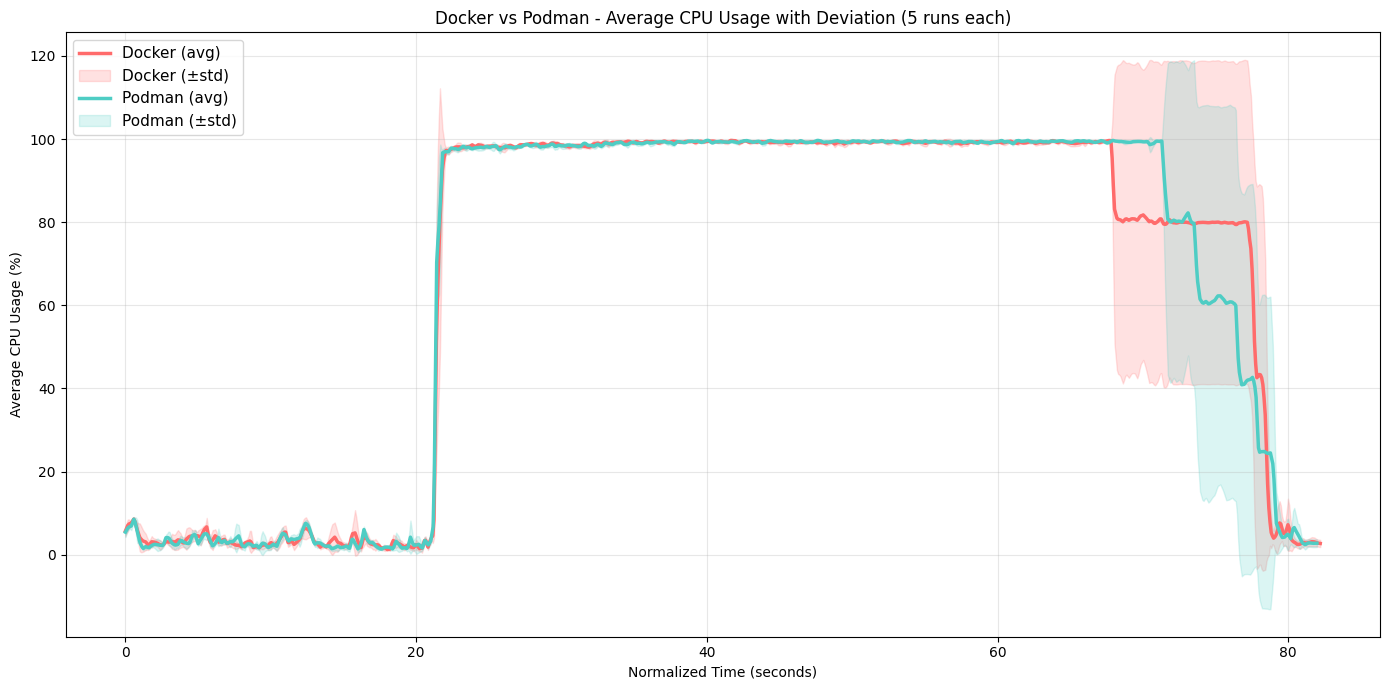

In [71]:
# Plot Docker vs Podman - averaged CPU usage with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_time, docker_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_time,
                  docker_mean - docker_std,
                  docker_mean + docker_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_time, podman_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_time,
                  podman_mean - podman_std,
                  podman_mean + podman_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Average CPU Usage (%)')
plt.title('Docker vs Podman - Average CPU Usage with Deviation (5 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot cumulative energy usage for Podman and Docker

In [72]:
# Calculate cumulative energy for each run
def calculate_energy(runs):
    """Calculate cumulative energy for each run using energy deltas"""
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)', 'PACKAGE_ENERGY (J)'] # no GPU used so PP1 is not included
    
    energy_runs = []
    for df in runs:
        df_energy = df.copy()
        # Normalize time to start at 0 (in seconds)
        df_energy['time'] = (df_energy['Time'] - df_energy['Time'].min()) / 1000
        
        # Calculate total energy by summing available energy columns
        available_cols = [col for col in energy_columns if col in df_energy.columns]
        
        if available_cols:
            # Sum energy deltas (difference from first measurement)
            df_energy['cumulative_energy'] = df_energy[available_cols].sum(axis=1) - df_energy[available_cols].iloc[0].sum()
        else:
            raise ValueError(f'No energy columns found. Available: {df_energy.columns.tolist()}')
        
        energy_runs.append(df_energy)
    
    return energy_runs

docker_energy_runs = calculate_energy(docker_runs)
podman_energy_runs = calculate_energy(podman_runs)

print('Energy calculated for all runs')

Energy calculated for all runs


In [63]:
# Normalize and average energy across runs
def average_energy_runs(runs):
    """Average cumulative energy across runs"""
    # Create common time axis
    max_time = max(df['time'].max() for df in runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Interpolate energy for each run
    all_energy_data = []
    for df in runs:
        energy_interp = np.interp(time_axis, df['time'], df['cumulative_energy'])
        all_energy_data.append(energy_interp)
    
    all_energy_data = np.array(all_energy_data)
    mean = all_energy_data.mean(axis=0)
    std = all_energy_data.std(axis=0)
    
    return time_axis, mean, std

docker_energy_time, docker_energy_mean, docker_energy_std = average_energy_runs(docker_energy_runs)
podman_energy_time, podman_energy_mean, podman_energy_std = average_energy_runs(podman_energy_runs)

print('Energy averaged across runs')

Energy averaged across runs


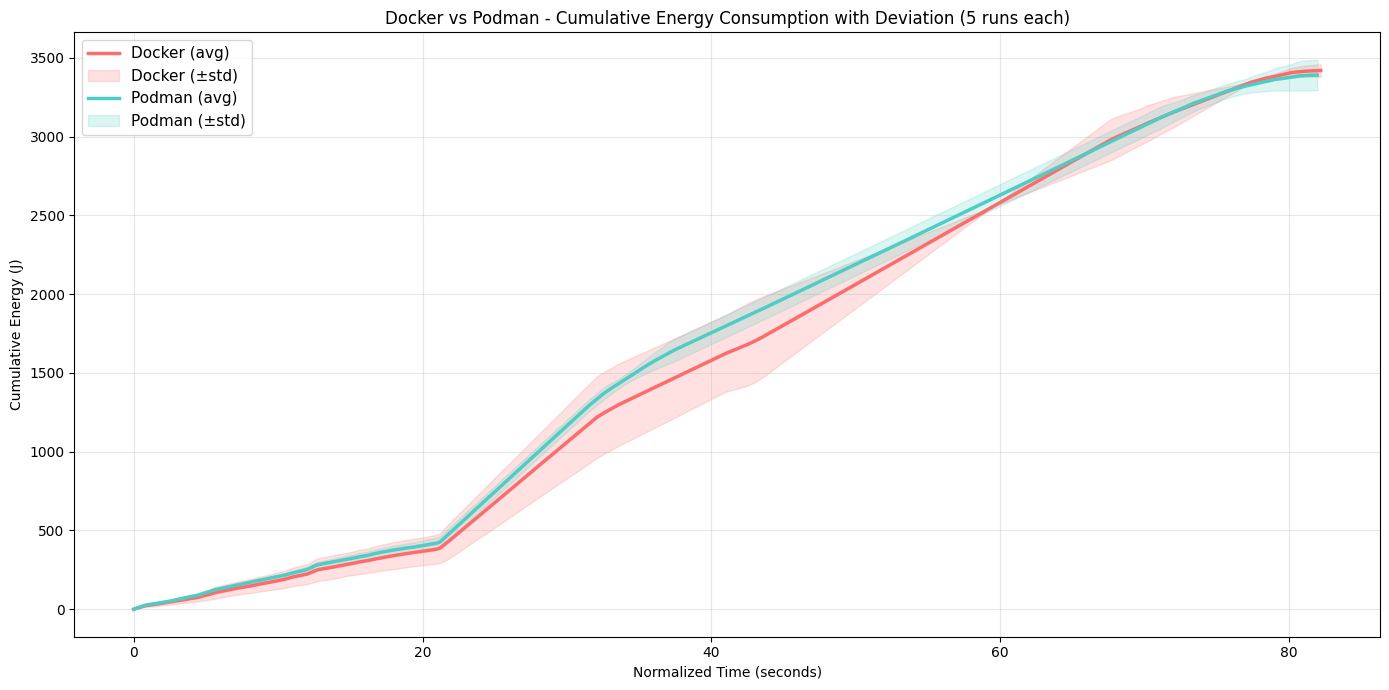

In [68]:
# Plot Docker vs Podman - averaged energy consumption with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_energy_time, docker_energy_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_energy_time,
                  docker_energy_mean - docker_energy_std,
                  docker_energy_mean + docker_energy_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_energy_time, podman_energy_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_energy_time,
                  podman_energy_mean - podman_energy_std,
                  podman_energy_mean + podman_energy_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Cumulative Energy (J)')
plt.title('Docker vs Podman - Cumulative Energy Consumption with Deviation (5 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Violin plots of cumulative energy usage

/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/2140735641.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])


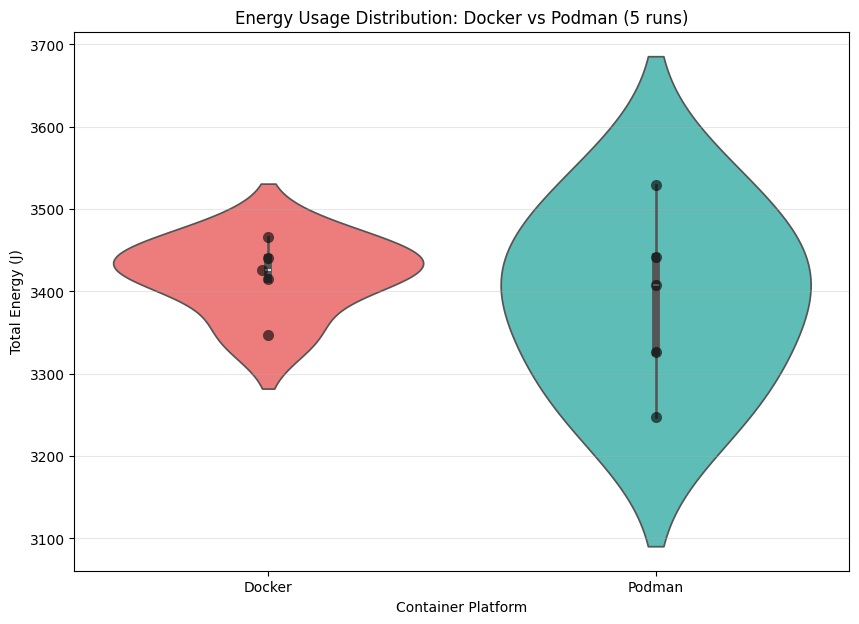

Docker - Mean: 3419.11 J, Std: 39.98 J
Podman - Mean: 3390.51 J, Std: 96.67 J


In [ ]:
import seaborn as sns

# Extract total energy for each run
docker_energies = [df['cumulative_energy'].iloc[-1] for df in docker_energy_runs]
podman_energies = [df['cumulative_energy'].iloc[-1] for df in podman_energy_runs]

# Create dataframe for violin plot
violin_data = pd.DataFrame({
    'platform': ['Docker'] * len(docker_energies) + ['Podman'] * len(podman_energies),
    'total_energy': docker_energies + podman_energies
})

# Create violin plot
plt.figure(figsize=(10, 7))
sns.violinplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])
sns.swarmplot(data=violin_data, x='platform', y='total_energy', color='black', alpha=0.6, size=8)

plt.ylabel('Total Energy (J)')
plt.xlabel('Container Platform')
plt.title('Energy Usage Distribution: Docker vs Podman (5 runs)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Docker - Mean: {np.mean(docker_energies):.2f} J, Std: {np.std(docker_energies):.2f} J')
print(f'Podman - Mean: {np.mean(podman_energies):.2f} J, Std: {np.std(podman_energies):.2f} J')

/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/555759074.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_data_halfway, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])


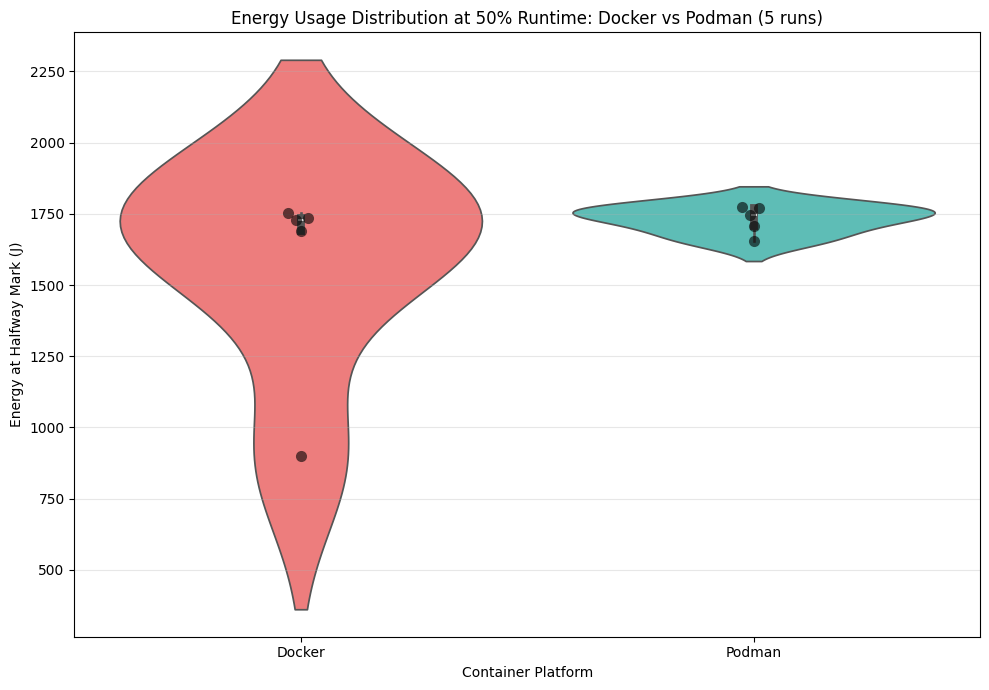

Docker (halfway) - Mean: 1561.02 J, Std: 331.52 J
Podman (halfway) - Mean: 1730.70 J, Std: 44.22 J


In [78]:
# Extract energy at halfway mark for each run
docker_energies_halfway = []
podman_energies_halfway = []

for df in docker_energy_runs:
    halfway_time = df['time'].max() / 2
    # Find closest index to halfway point
    closest_idx = (df['time'] - halfway_time).abs().idxmin()
    docker_energies_halfway.append(df['cumulative_energy'].iloc[closest_idx])

for df in podman_energy_runs:
    halfway_time = df['time'].max() / 2
    closest_idx = (df['time'] - halfway_time).abs().idxmin()
    podman_energies_halfway.append(df['cumulative_energy'].iloc[closest_idx])

# Create dataframe for violin plot
violin_data_halfway = pd.DataFrame({
    'platform': ['Docker'] * len(docker_energies_halfway) + ['Podman'] * len(podman_energies_halfway),
    'total_energy': docker_energies_halfway + podman_energies_halfway
})

# Create violin plot
plt.figure(figsize=(10, 7))
sns.violinplot(data=violin_data_halfway, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])
sns.swarmplot(data=violin_data_halfway, x='platform', y='total_energy', color='black', alpha=0.6, size=8)

plt.ylabel('Energy at Halfway Mark (J)')
plt.xlabel('Container Platform')
plt.title('Energy Usage Distribution at 50% Runtime: Docker vs Podman (5 runs)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Docker (halfway) - Mean: {np.mean(docker_energies_halfway):.2f} J, Std: {np.std(docker_energies_halfway):.2f} J')
print(f'Podman (halfway) - Mean: {np.mean(podman_energies_halfway):.2f} J, Std: {np.std(podman_energies_halfway):.2f} J')

### Total view of energy used in experiment

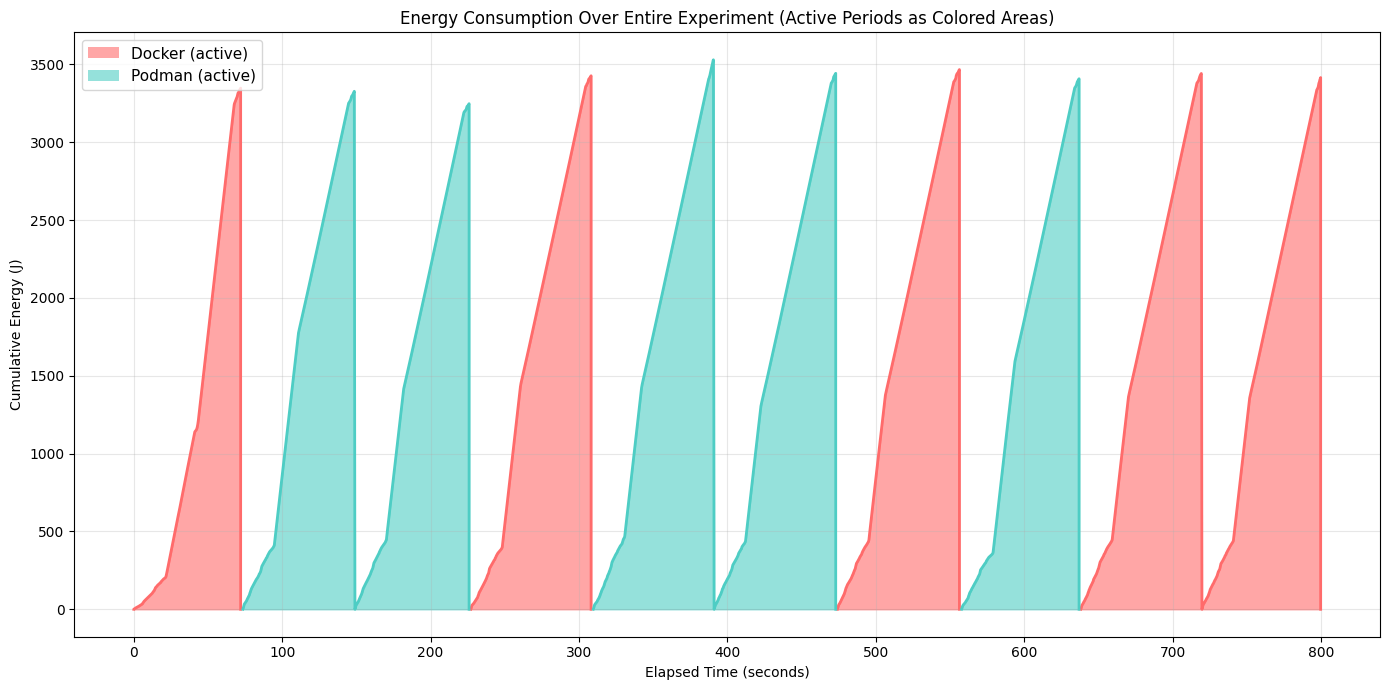

In [ ]:
# Energy plot which shows overview of all experiments
# Combine all runs with platform labels
all_samples = []

for df in docker_energy_runs:
    df_copy = df.copy()
    df_copy['platform'] = 'Docker'
    all_samples.append(df_copy)

for df in podman_energy_runs:
    df_copy = df.copy()
    df_copy['platform'] = 'Podman'
    all_samples.append(df_copy)

df_all = pd.concat(all_samples, ignore_index=True)

# Normalize time across entire experiment
min_time = df_all['Time'].min()
max_time = df_all['Time'].max()
df_all['elapsed_time'] = (df_all['Time'] - min_time) / 1000

# Separate by platform
docker_data = df_all[df_all['platform'] == 'Docker'].sort_values('elapsed_time').reset_index(drop=True)
podman_data = df_all[df_all['platform'] == 'Podman'].sort_values('elapsed_time').reset_index(drop=True)

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Docker segments
docker_segments = []
current_segment = []
for idx, row in docker_data.iterrows():
    current_segment.append(row)
    # Check if this is the last row or if there's a gap to the next
    if idx == len(docker_data) - 1 or (docker_data.loc[idx + 1, 'elapsed_time'] - row['elapsed_time']) > 5:
        docker_segments.append(pd.DataFrame(current_segment))
        current_segment = []

# Plot each Docker segment with vertical drop
for segment in docker_segments:
    segment_with_drop = pd.concat([segment, pd.DataFrame([{'elapsed_time': segment.iloc[-1]['elapsed_time'], 'cumulative_energy': 0}])], ignore_index=True)
    ax.fill_between(segment_with_drop['elapsed_time'], 0, segment_with_drop['cumulative_energy'],
                    color='#FF6B6B', alpha=0.6)
    ax.plot(segment_with_drop['elapsed_time'], segment_with_drop['cumulative_energy'],
           linewidth=2, color='#FF6B6B')

# Plot Podman segments
podman_segments = []
current_segment = []
for idx, row in podman_data.iterrows():
    current_segment.append(row)
    if idx == len(podman_data) - 1 or (podman_data.loc[idx + 1, 'elapsed_time'] - row['elapsed_time']) > 5:
        podman_segments.append(pd.DataFrame(current_segment))
        current_segment = []

# Plot each Podman segment with vertical drop
for segment in podman_segments:
    segment_with_drop = pd.concat([segment, pd.DataFrame([{'elapsed_time': segment.iloc[-1]['elapsed_time'], 'cumulative_energy': 0}])], ignore_index=True)
    ax.fill_between(segment_with_drop['elapsed_time'], 0, segment_with_drop['cumulative_energy'],
                    color='#4ECDC4', alpha=0.6)
    ax.plot(segment_with_drop['elapsed_time'], segment_with_drop['cumulative_energy'],
           linewidth=2, color='#4ECDC4')

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.6, label='Docker (active)'),
                  Patch(facecolor='#4ECDC4', alpha=0.6, label='Podman (active)')]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

ax.set_xlabel('Elapsed Time (seconds)')
ax.set_ylabel('Cumulative Energy (J)')
ax.set_title('Energy Consumption Over Entire Experiment (Active Periods as Colored Areas)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
from scipy.stats import shapiro

# Extract final energy values for each run
docker_energies = [df['cumulative_energy'].iloc[-1] for df in docker_energy_runs]
podman_energies = [df['cumulative_energy'].iloc[-1] for df in podman_energy_runs]

# Perform Shapiro-Wilks test
docker_stat, docker_p = shapiro(docker_energies)
podman_stat, podman_p = shapiro(podman_energies)

# Display results
print('Shapiro-Wilks Normality Test')
print('=' * 50)
print(f'Docker:')
print(f'  Test Statistic: {docker_stat:.6f}')
print(f'  P-value: {docker_p:.6f}')
print(f'  Normal Distribution: {"Yes (p > 0.05)" if docker_p > 0.05 else "No (p < 0.05)"}')
print()
print(f'Podman:')
print(f'  Test Statistic: {podman_stat:.6f}')
print(f'  P-value: {podman_p:.6f}')
print(f'  Normal Distribution: {"Yes (p > 0.05)" if podman_p > 0.05 else "No (p < 0.05)"}')

Shapiro-Wilks Normality Test
Docker:
  Test Statistic: 0.917139
  P-value: 0.511653
  Normal Distribution: Yes (p > 0.05)

Podman:
  Test Statistic: 0.990553
  P-value: 0.981595
  Normal Distribution: Yes (p > 0.05)
